<a href="https://colab.research.google.com/github/mananmalvi/deep-learning-projects/blob/main/STAR_stapio_temporal_action_recogination_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import glob # glob is a Python module used for file pattern matching, allowing you to retrieve file paths that match a specified pattern (e.g., *.txt)
import pandas as pd
import cv2 # cv2 is a Python library that provides functions for image processing and computer vision tasks, such as reading, writing, and manipulating images, as well as performing tasks like object detection and feature extraction.
import gc # gc is a Python module that provides functions to interact with the garbage collection process, allowing manual control over memory management, such as forcing garbage collection or disabling it. It helps optimize memory usage and clean up unused objects.
import numpy as np
import random
import imageio # imageio is a Python library used for reading and writing image data, supporting a wide range of image formats and providing easy interfaces for handling images, videos, and volumes.
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython.display import display, Image  # display images and other rich media in Jupyter notebooks or IPython environments.display is used to render objects in the output cell. Image is used to display an image from a file or URL.
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
!rm -rf /content/UCF101_dataset !rm -rf /content/kaggle_temp

In [ ]:
import os

# 1. Naya API Token
# (Note: Agar Kaggle API strictly Username/Key mange, toh aage bataya gaya backup option use karna)
os.environ["KAGGLE_API_TOKEN"] = "KGAT_bc7c162a737a932de95e6a49dfa0a4e6"

# 2. Puraane kachre ko saaf karo taaki RAM/Disk free rahe
!rm -rf /content/UCF101_dataset
!rm -f ucf101.zip

# 3. Download from Kaggle (Colab server pe ye bohot fast hoga)
print("Downloading UCF101 Dataset...")
!kaggle datasets download -d pevogam/ucf101

# 4. Unzip directly into our working folder (-q for quiet mode taaki screen na bhare)
print("Unzipping dataset... (This takes about 1 minute)")
!unzip -q ucf101.zip -d /content/UCF101_dataset

print("✅ Dataset successfully downloaded, unzipped, and ready for STAR AI!")

Dataset URL: https://www.kaggle.com/datasets/pevogam/ucf101
License(s): copyright-authors
100% 6.49G/6.49G [01:10<00:00, 98.2MB/s]

Unzipping dataset... (This takes about 1 minute)
✅ Dataset successfully downloaded, unzipped, and ready for STAR AI!


In [ ]:
# Your 3 target classes
classes = ["ApplyEyeMakeup", "ApplyLipstick", "Archery"]
DATASET_PATH = "/content/UCF101_dataset"

file_paths, targets = [], []

for i, cls in enumerate(classes):
    # The /**/ tells glob to look inside ALL nested subfolders
    search_pattern = f"{DATASET_PATH}/**/{cls}/*.avi"
    video_files = glob.glob(search_pattern, recursive=True)

    file_paths.extend(video_files)
    targets.extend([i] * len(video_files))

print(f"Loaded {len(file_paths)} videos for training.")

Loaded 404 videos for training.


In [ ]:
file_paths[0:6]

['/content/UCF101_dataset/UCF101/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g07_c05.avi',
 '/content/UCF101_dataset/UCF101/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g24_c04.avi',
 '/content/UCF101_dataset/UCF101/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g13_c01.avi',
 '/content/UCF101_dataset/UCF101/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g06_c04.avi',
 '/content/UCF101_dataset/UCF101/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g20_c04.avi',
 '/content/UCF101_dataset/UCF101/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g12_c02.avi']

In [ ]:
targets[:5]

[0, 0, 0, 0, 0]

In [ ]:
# Use Keras-based resizing and scaling
def format_frames(frame, output_size=(224, 224)):
    frame = tf.keras.layers.Rescaling(1.0 / 255.0)(frame)  # Normalize pixel values to [0,1]
    frame = tf.image.resize_with_pad(frame, *output_size)  # Resize while maintaining aspect ratio with padding
    return frame

# Read and process video frames
def frames_from_video_file(video_path, n_frames=10, output_size=(224, 224), frame_step=15):
    result = []  # Store extracted frames
    src = cv2.VideoCapture(video_path)  # Open video file
    video_length = int(src.get(cv2.CAP_PROP_FRAME_COUNT))  # Get total number of frames in the video

    # Randomly select a starting frame within valid range
    start = random.randint(0, max(0, video_length - 1 - (n_frames - 1) * frame_step))
    src.set(cv2.CAP_PROP_POS_FRAMES, start)  # Set the video frame position to start point

    ret, frame = src.read()  # Read the first frame
    if ret:  # If frame is successfully read
        result.append(format_frames(frame, output_size))  # Process and store the frame

        for _ in range(n_frames - 1):  # Loop to extract remaining frames
            for _ in range(frame_step):  # Skip `frame_step` frames to maintain spacing
                src.read()  # Read and discard the skipped frames

            ret, frame = src.read()  # Read the next valid frame
            if ret:
                result.append(format_frames(frame, output_size))  # Process and store frame
            else:
                result.append(tf.zeros_like(result[0]))  # Add a black frame if the video ends early

    src.release()  # Release the video file
    return np.array(result)[..., [2, 1, 0]]  # Convert BGR to RGB format


# Prepare training and validation datasets
# features = np.array([frames_from_video_file(f, n_frames=10) for f in tqdm(file_paths)])  # Extract frames from videos

# Convert targets into a NumPy array for compatibility
# targets = np.array(targets)

In [ ]:
# features.shape

In [ ]:
len(targets)

404

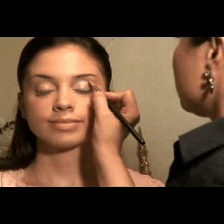

In [ ]:
# Convert frames to GIF for visualization
def to_gif(images):
    images = np.clip(images * 255, 0, 255).astype(np.uint8)
    imageio.mimsave('./animation.gif', images, fps=10)
    display(Image(filename='./animation.gif'))

# Visualize sample video
sample_video = frames_from_video_file(file_paths[0], n_frames=10)
to_gif(sample_video)

In [ ]:
# Convert targets into a NumPy array
targets = np.array(targets)

# Train-test split (Splitting the paths, not the heavy videos)
train_paths, val_paths, train_targets, val_targets = train_test_split(
    file_paths, targets, test_size=0.2, random_state=42
)

# The Generator that loads 8 videos at a time
class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, labels, batch_size=8):
        self.paths = paths
        self.labels = labels
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.paths) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_x_paths = self.paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.labels[idx * self.batch_size:(idx + 1) * self.batch_size]

        X = np.array([frames_from_video_file(f, n_frames=10) for f in batch_x_paths])
        y = np.array(batch_y)
        return X, y

# Initialize the generators
train_gen = VideoDataGenerator(train_paths, train_targets)
valid_gen = VideoDataGenerator(val_paths, val_targets)

In [ ]:
targets.shape

(404,)

In [ ]:
'''# Train-test split (80% training, 20% validation)
train_features, val_features, train_targets, val_targets = train_test_split(
    features, targets, test_size=0.2, random_state=42  # Ensure reproducibility
)

batch_size = 32 # Define batch_size

# Create an optimized training dataset pipeline using tf.data
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_features, train_targets))  # Convert data into a TensorFlow dataset
    .shuffle(len(train_features))  # Shuffle data to improve training performance
    .batch(batch_size)  # Group data into batches
    .cache()  # Cache data to speed up processing
    .prefetch(tf.data.AUTOTUNE)  # Optimize performance by prefetching data
)

# Create an optimized validation dataset pipeline
valid_ds = (
    tf.data.Dataset.from_tensor_slices((val_features, val_targets))  # Convert validation data into a dataset
    .batch(batch_size)  # Batch validation data
    .cache()  # Cache to speed up validation
    .prefetch(tf.data.AUTOTUNE)  # Optimize performance by prefetching
)

# Cleanup unused variables to free up memory
del features, targets
gc.collect()  # Trigger garbage collection '''

In [ ]:
from tensorflow import keras

# Load the EfficientNetB0 model without the top classification layer
net = keras.applications.EfficientNetB0(include_top=False)
net.trainable = False  # Freeze the base model to use pre-trained weights


# Define a Sequential model with EfficientNet as a feature extractor
efficient_net_model = keras.Sequential([
    keras.layers.Rescaling(255.0),  # Rescale input pixel values
    keras.layers.TimeDistributed(net),  # Apply the EfficientNet model to each frame separately
    keras.layers.Dense(len(classes)),  # Output layer with the number of classes
    keras.layers.GlobalAveragePooling3D()  # Pooling layer to reduce dimensions
])

# Compile the model with Adam optimizer and sparse categorical cross-entropy loss
efficient_net_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),  # Suitable for integer labels
    metrics=['accuracy']  # Track accuracy during training
)

"""# Define an early stopping callback to stop training if validation loss doesn't improve
early_stopping = keras.callbacks.EarlyStopping(patience=2, monitor='val_loss')

# Define the number of epochs
epochs = 10

# Train the model with the training dataset and validate on validation data
history = efficient_net_model.fit(
    train_gen,
    epochs=epochs,
    validation_data=valid_gen,
    callbacks=[early_stopping]  # Apply early stopping to prevent overfitting
)"""
# ✅ YAHAN NAYA CODE PASTE KARO ✅
import gc
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
import tensorflow as tf

# 1. Early Stopping
early_stopping = EarlyStopping(patience=2, monitor='val_loss')

# 2. Model Checkpoint (Google Drive mein save karne ke liye)
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/action_model_safe.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# 3. Memory Cleaner (Har epoch ke baad RAM saaf karne ke liye)
class MemoryCleaner(Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        tf.keras.backend.clear_session()
        print(f"\n🧹 RAM cleared after Epoch {epoch + 1}!")

safeguard_callbacks = [early_stopping, checkpoint, MemoryCleaner()]

# 4. Start Training
epochs = 10
print("Starting bulletproof training... Model will be saved to Google Drive.")
history = efficient_net_model.fit(
    train_gen,
    epochs=epochs,
    validation_data=valid_gen,
    callbacks=safeguard_callbacks
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting bulletproof training... Model will be saved to Google Drive.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5899 - loss: 0.8508
Epoch 1: val_accuracy improved from None to 0.92593, saving model to /content/drive/MyDrive/action_model_safe.h5



Epoch 1: finished saving model to /content/drive/MyDrive/action_model_safe.h5

🧹 RAM cleared after Epoch 1!
41/41 ━━━━━━━━━━━━━━━━━━━━ 398s 5s/step - accuracy: 0.7802 - loss: 0.6182 - val_accuracy: 0.9259 - val_loss: 0.3875
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9752 - loss: 0.2613
Epoch 2: val_accuracy improved from 0.92593 to 0.96296, saving model to /content/drive/MyDrive/action_model_safe.h5



Epoch 2: finished saving model to /content/drive/MyDrive/action_model_safe.h5

🧹 RAM cleared after Epoch 2!
41/41 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9690 - loss: 0.2505 - val_accuracy: 0.9630 - val_loss: 0.2588
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9780 - loss: 0.1816
Epoch 3: val_accuracy improved from 0.96296 to 0.97531, saving model to /content/drive/MyDrive/action_model_safe.h5



Epoch 3: finished saving model to /content/drive/MyDrive/action_model_safe.h5

🧹 RAM cleared after Epoch 3!
41/41 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9814 - loss: 0.1619 - val_accuracy: 0.9753 - val_loss: 0.1726
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9874 - loss: 0.1371
Epoch 4: val_accuracy did not improve from 0.97531

🧹 RAM cleared after Epoch 4!
41/41 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9938 - loss: 0.1179 - val_accuracy: 0.9753 - val_loss: 0.1474
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9983 - loss: 0.0841
Epoch 5: val_accuracy did not improve from 0.97531

🧹 RAM cleared after Epoch 5!
41/41 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9938 - loss: 0.0902 - val_accuracy: 0.9753 - val_loss: 0.1422
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9969 - loss: 0.0774
Epoch 6: val_accuracy did not improve from 0.97531

🧹 RAM cleared after Epoch 6!
41/41 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9


Epoch 7: finished saving model to /content/drive/MyDrive/action_model_safe.h5

🧹 RAM cleared after Epoch 7!
41/41 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 1.0000 - loss: 0.0618 - val_accuracy: 0.9877 - val_loss: 0.0975
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 0.0550
Epoch 8: val_accuracy did not improve from 0.98765

🧹 RAM cleared after Epoch 8!
41/41 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 1.0000 - loss: 0.0523 - val_accuracy: 0.9877 - val_loss: 0.0820
Epoch 9/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 0.0454
Epoch 9: val_accuracy did not improve from 0.98765

🧹 RAM cleared after Epoch 9!
41/41 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 1.0000 - loss: 0.0456 - val_accuracy: 0.9877 - val_loss: 0.0735
Epoch 10/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9987 - loss: 0.0418
Epoch 10: val_accuracy did not improve from 0.98765

🧹 RAM cleared after Epoch 10!
41/41 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 

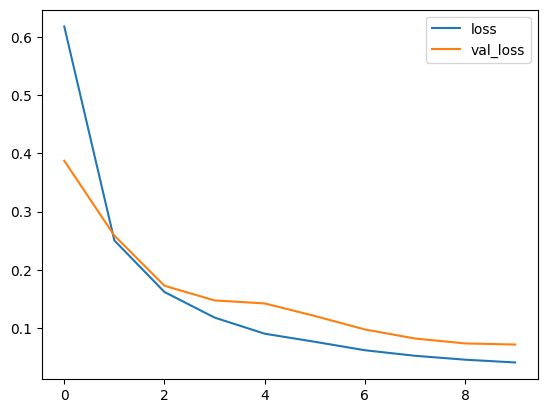

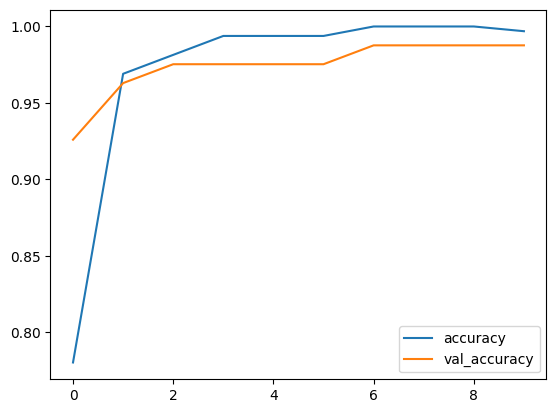

In [ ]:
for metrics in [("loss", "val_loss"), ("accuracy", "val_accuracy")]:
    pd.DataFrame(history.history, columns=metrics).plot()
    plt.show

In [ ]:
val_loss, val_acc = efficient_net_model.evaluate(valid_gen)
print(f"Validation Loss:{val_loss} Validation Accuracy:{val_acc}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 911ms/step - accuracy: 0.9877 - loss: 0.0740
Validation Loss:0.07404163479804993 Validation Accuracy:0.9876543283462524


In [ ]:
# Get true labels
y_true = np.concatenate([y for x, y in valid_gen], axis=0)

# Get model predictions (convert logits to class indices)
y_pred_logits = efficient_net_model.predict(valid_gen)
y_pred = np.argmax(y_pred_logits, axis=1)  # Convert logits to class indices

# Generate classification report
class_report = classification_report(y_true, y_pred, target_names=classes)
print("Classification Report:\n", class_report)

11/11 ━━━━━━━━━━━━━━━━━━━━ 60s 6s/step
Classification Report:
                 precision    recall  f1-score   support

ApplyEyeMakeup       1.00      0.97      0.99        36
 ApplyLipstick       0.95      1.00      0.97        18
       Archery       1.00      1.00      1.00        27

      accuracy                           0.99        81
     macro avg       0.98      0.99      0.99        81
  weighted avg       0.99      0.99      0.99        81



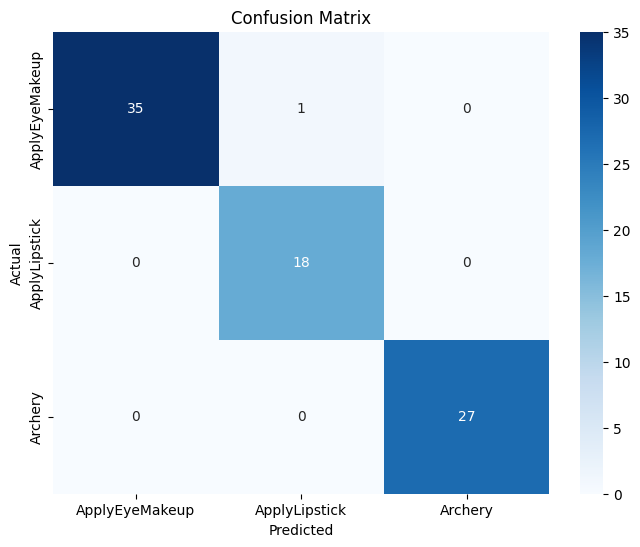

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

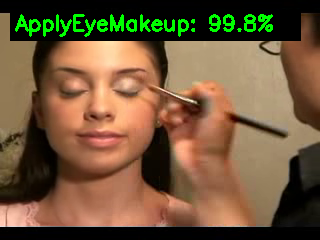


✅ Processing complete! The video with the bounding box has been saved as '/content/output.avi'.
You can download it from the left sidebar to show your professors!


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import time
from IPython.display import display, clear_output
import PIL.Image

def detect_video(video_path, model, class_names, n_frames=10, output_size=(224, 224)):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Could not open video at {video_path}")
        return

    # Define video writer for output (saving the video)
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    # Save it to /content so you can easily download it later
    out = cv2.VideoWriter('/content/output.avi', fourcc, 20.0, (int(cap.get(3)), int(cap.get(4))))

    print("Processing video... This may take a moment.")

    # We will read the whole video frame by frame
    frames_buffer = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break # Video is over

        # 1. Preprocess the frame for the model
        frame_resized = cv2.resize(frame, output_size)
        frame_resized = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB) # Ensure RGB
        frame_resized = frame_resized / 255.0
        frames_buffer.append(frame_resized)

        # We need to wait until we have 10 frames before we can make a prediction
        if len(frames_buffer) >= n_frames:
            # Take the last 10 frames
            model_input = np.array(frames_buffer[-n_frames:])
            model_input = np.expand_dims(model_input, axis=0)

            # Predict Action
            predictions = model.predict(model_input, verbose=0)
            class_idx = np.argmax(predictions)

            # Since you compiled with from_logits=True, we use softmax to get a percentage
            confidence = np.max(tf.nn.softmax(predictions)) * 100

            # 2. Draw on the ORIGINAL frame
            # Draw a black rectangle for the label background
            cv2.rectangle(frame, (10, 10), (300, 40), (0, 0, 0), -1)

            # Draw prediction text (e.g., "Archery: 98.5%")
            text = f"{class_names[class_idx]}: {confidence:.1f}%"
            cv2.putText(frame, text, (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # 3. Write to output file and Display
        out.write(frame)

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        clear_output(wait=True)
        img = PIL.Image.fromarray(frame_rgb)
        display(img)

        # Add small delay for smooth playback
        time.sleep(0.01)

    cap.release()
    out.release()
    print("\n✅ Processing complete! The video with the bounding box has been saved as '/content/output.avi'.")
    print("You can download it from the left sidebar to show your professors!")

# --- Let's test it on a random video from your dataset! ---
# We will grab the very first video from your file_paths list
test_video_path = file_paths[0]
print(f"Testing on video: {test_video_path}")

detect_video(test_video_path, efficient_net_model, classes)

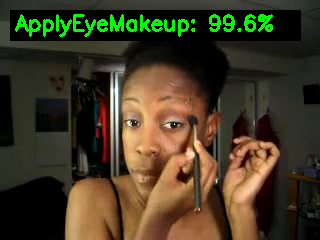


✅ Processing complete! The video with the bounding box has been saved as '/content/output.avi'.
You can download it from the left sidebar to show your professors!


In [ ]:
import random

# Option 1A: Test on a completely random video from your dataset
random_video = random.choice(file_paths)
print(f"Testing on random video: {random_video}")
detect_video(random_video, efficient_net_model, classes)


--- Running Option 1A ---
Testing on random video: /content/UCF101_dataset/UCF101/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g05_c07.avi
Processing video... Butter-smooth playback, no flickering! 🚀


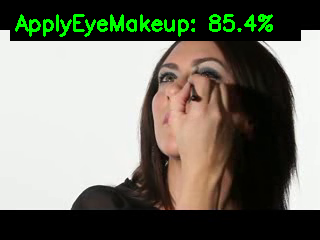

KeyboardInterrupt: 

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import time
from IPython.display import display
import PIL.Image
import random

# --- 1. THE FLICKER-FREE FUNCTION ---
def detect_video(video_path, model, class_names, n_frames=10, output_size=(224, 224)):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Could not open video at {video_path}")
        return

    print("Processing video... Butter-smooth playback, no flickering! 🚀")

    frames_buffer = []

    # 🔥 YAHAN HAI MAGIC FIX! Ek permanent display screen bana lo 🔥
    video_display = display(display_id=True)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break # Video is over

        # Preprocess frame
        frame_resized = cv2.resize(frame, output_size)
        frame_resized = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB)
        frame_resized = frame_resized / 255.0
        frames_buffer.append(frame_resized)

        # Buffer manage karo (RAM bachane ke liye)
        if len(frames_buffer) > n_frames:
            frames_buffer.pop(0)

        # Action Predict karo
        if len(frames_buffer) == n_frames:
            model_input = np.array(frames_buffer)
            model_input = np.expand_dims(model_input, axis=0)

            # Direct call to prevent TF loop crashes
            predictions = model(model_input, training=False)
            class_idx = np.argmax(predictions)
            confidence = np.max(tf.nn.softmax(predictions)) * 100

            # Video pe box aur text draw karo
            cv2.rectangle(frame, (10, 10), (300, 40), (0, 0, 0), -1)
            text = f"{class_names[class_idx]}: {confidence:.1f}%"
            cv2.putText(frame, text, (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # Frame ko display ke liye ready karo
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = PIL.Image.fromarray(frame_rgb)

        # 🔥 YAHAN DUSRA MAGIC! Nayi image banne ki jagah, purani update hogi 🔥
        video_display.update(img)

    cap.release()
    print("\n✅ Video Processing Complete!")


# --- 2. RUN THE TEST (Tumhara diya hua code) ---

# Option 1A: Test on a completely random video from your dataset
print("\n--- Running Option 1A ---")
random_video = random.choice(file_paths)
print(f"Testing on random video: {random_video}")
detect_video(random_video, efficient_net_model, classes)


--- Running Option 1B ---
Testing specifically on: /content/UCF101_dataset/UCF101/UCF-101/Archery/v_Archery_g21_c03.avi
Processing video... Butter-smooth playback, no flickering! 🚀


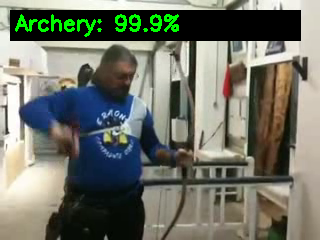

KeyboardInterrupt: 

In [ ]:
# Option 1B: Test an "Archery" video
print("\n--- Running Option 1B ---")
archery_videos = [path for path in file_paths if "Archery" in path]
test_video = archery_videos[0] # Picks the first archery video
print(f"Testing specifically on: {test_video}")
detect_video(test_video, efficient_net_model, classes)

In [ ]:
# Pickle ki jagah .save() use karte hain keras mein
efficient_net_model.save('/content/final_action_model.h5')

print("✅ Model successfully saved as .h5! Ab tum ise left sidebar se download kar sakte ho.")

✅ Model successfully saved as .h5! Ab tum ise left sidebar se download kar sakte ho.


SHOW MODEL

In [ ]:
# Apna saved model direct load karo,
from tensorflow.keras.models import load_model


loaded_model = load_model('/content/final_action_model.h5') # Ya Drive wala path daal dena

print("Model successfully loaded! Ready for predictions.")

Model successfully loaded! Ready for predictions.


In [ ]:
# Yeh line file create karti hai
efficient_net_model.save('final_action_model.h5')

# Yeh line tumhare computer mein download start kar degi
from google.colab import files
files.download('final_action_model.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.path.exists('/content/final_action_model.h5'))


True


### 1. Install Streamlit and other necessary libraries

First, we need to install `streamlit`, `opencv-python-headless` (for image processing without GUI dependencies), and `imageio-ffmpeg` which `imageio` sometimes relies on for video processing.

### 2. Create the Streamlit Application (`app.py`)

This script will contain the logic for our web application. It will:
- Load the pre-trained `efficient_net_model`.
- Provide a file uploader for video files.
- Use the `detect_video` function (adapted for Streamlit) to process the uploaded video and display real-time predictions.

### 3. Run the Streamlit Application

After creating `app.py`, we can run it using the `streamlit run` command. We'll use `npx localtunnel` to expose the Streamlit app running on Colab's internal port (8501) to a public URL, which you can then access in your browser.

In [ ]:
!pip install -q gradio

In [ ]:
!pip install -q gradio nest-asyncio

In [ ]:
!pip install -q gradio uvicorn==0.29.0 nest-asyncio

In [ ]:
%%writefile app.py
import gradio as gr
import cv2
import numpy as np
import tensorflow as tf
import logging
import os

logging.getLogger("tensorflow").setLevel(logging.ERROR)

# --- 1. SETUP & MODEL LOADING ---
CLASSES = ["ApplyEyeMakeup", "ApplyLipstick", "Archery"]
IMG_SIZE = 224
MAX_FRAMES = 10

print("⏳ Loading Model...")
try:
    model = tf.keras.models.load_model('/content/final_action_model.h5')
    print("✅ Model Loaded Successfully! Ready for Presentation 🚀")
except Exception as e:
    print(f"❌ Error: {e}")
    model = None

# --- 2. VIDEO PROCESSING LOGIC ---
def predict_action(video_path):
    if model is None:
        return {"❌ ERROR: Model (.h5) upload nahi hua hai!": 1.0}
    if video_path is None:
        return {"❌ ERROR: Please upload a video": 1.0}

    cap = cv2.VideoCapture(video_path)
    frames = []

    while cap.isOpened() and len(frames) < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame / 255.0)
    cap.release()

    while len(frames) < MAX_FRAMES:
        frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))

    input_data = np.expand_dims(np.array(frames), axis=0)
    predictions = model.predict(input_data, verbose=0)[0]
    confidence_scores = tf.nn.softmax(predictions).numpy()

    return {CLASSES[i]: float(confidence_scores[i]) for i in range(len(CLASSES))}

# --- 3. GRADIO UI DESIGN ---
custom_css = """
body { background-color: #0f141e; }
h1 { color: #3b82f6 !important; text-shadow: 0px 0px 15px rgba(59, 130, 246, 0.8); text-align: center; font-size: 40px !important; font-weight: bold; }
h3 { color: #8b949e !important; text-align: center; letter-spacing: 2px; }
"""

with gr.Blocks(css=custom_css) as demo:
    gr.Markdown("# STAR AI")
    gr.Markdown("### SPATIO-TEMPORAL ACTION RECOGNITION")

    with gr.Row():
        with gr.Column():
            video_input = gr.Video(label="Upload Video here")
            predict_btn = gr.Button("Detect Action 🚀", variant="primary")

        with gr.Column():
            output_label = gr.Label(num_top_classes=3, label="Detection Result")

    predict_btn.click(fn=predict_action, inputs=video_input, outputs=output_label)

# --- 4. LAUNCH PUBLIC LINK ---
demo.launch(share=True)

Writing app.py


In [ ]:
!python app.py

2026-05-18 06:32:04.153069: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
⏳ Loading Model...
2026-05-18 06:32:09.912163: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1779085929.913637    5767 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
✅ Model Loaded Successfully! Ready for Presentation 🚀
/content/app.py:57: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instea